In [63]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load the data
df = pd.read_csv('survey_results_shortened.csv')

# Display first few rows and dataset info
print("Data shape:", df.shape)
df.head()

Data shape: (47723, 149)


,MainBranch,Age,MaxAge,AgeNum,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,...,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,i am a developer by profession,25-34 years old,34.0,29.0,master's degree,employed,"['caring for dependents (children, elderly, et...",8.0,"yes, i am not new to coding but am learning ne...",['online courses or certification (includes al...,...,['vertex ai'],[],[],[],['chatgpt'],[],"[""when i don't trust ai's answers""]","['troubleshooting, profiling, debugging']",61256.0,10.0
1,i am a developer by profession,25-34 years old,34.0,29.0,associate degree,employed,[],2.0,"yes, i am not new to coding but am learning ne...","['books / physical media', 'online courses or ...",...,[],[],[],[],[],[],"[""when i don't trust ai's answers"", 'when i ha...",['all skills. ai is a flop.'],104413.0,9.0
2,i am a developer by profession,35-44 years old,44.0,39.0,bachelor's degree,"independent contractor, freelancer, or self-em...",['none of the above'],10.0,"yes, i am not new to coding but am learning ne...",['online courses or certification (includes al...,...,[],[],[],[],"['chatgpt', 'claude code', 'github copilot', '...",[],"[""when i don't trust ai's answers"", 'when i ha...","['understand how things actually work, problem...",53061.0,8.0
3,i am a developer by profession,35-44 years old,44.0,39.0,bachelor's degree,employed,['none of the above'],4.0,"yes, i am not new to coding but am learning ne...","['ai codegen tools or ai-enabled apps', 'other...",...,[],[],[],[],"['chatgpt', 'claude code']",[],"[""when i don't trust ai's answers"", 'when i ha...",[],36197.0,6.0
4,i am a developer by profession,35-44 years old,44.0,39.0,master's degree,"independent contractor, freelancer, or self-em...","['caring for dependents (children, elderly, et...",21.0,"no, i am not new to coding and did not learn n...",[],...,[],[],[],[],[],[],"[""when i don't trust ai's answers""]","['critical thinking, the skill to define the t...",60000.0,7.0


In [64]:
# Zeigt die numerischen Spalten an
df.select_dtypes(include=['int64', 'float64']).info()

# Oder für eine kompakte Übersicht:
print("\nNumerische Spalten:")
print(df.select_dtypes(include=['int64', 'float64']).columns.tolist())

# Für eine statistische Übersicht:
print("\nStatistische Zusammenfassung:")
df.select_dtypes(include=['int64', 'float64']).describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47723 entries, 0 to 47722
Data columns (total 43 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   MaxAge               47723 non-null  float64
 1   AgeNum               47723 non-null  float64
 2   WorkExp              41697 non-null  float64
 3   YearsCode            41789 non-null  float64
 4   RemoteCategoryNum    33257 non-null  float64
 5   TechEndorse_1        34913 non-null  float64
 6   TechEndorse_2        34913 non-null  float64
 7   TechEndorse_3        34913 non-null  float64
 8   TechEndorse_4        34913 non-null  float64
 9   TechEndorse_5        34913 non-null  float64
 10  TechEndorse_6        34913 non-null  float64
 11  TechEndorse_7        34913 non-null  float64
 12  TechEndorse_8        34913 non-null  float64
 13  TechEndorse_9        34913 non-null  float64
 14  TechEndorse_13       34913 non-null  float64
 15  TechOppose_1         33236 non-null 

,MaxAge,AgeNum,WorkExp,YearsCode,RemoteCategoryNum,TechEndorse_1,TechEndorse_2,TechEndorse_3,TechEndorse_4,TechEndorse_5,...,JobSatPoints_11,JobSatPoints_13,JobSatPoints_14,JobSatPoints_15,JobSatPoints_16,ToolCountWork,ToolCountPersonal,CompTotal,ConvertedCompYearly,JobSat
count,47723.000000,47723.000000,41697.000000,41789.000000,33257.000000,34913.000000,34913.000000,34913.000000,34913.000000,34913.000000,...,24497.000000,24497.000000,24497.000000,24497.000000,24497.000000,27065.000000,24743.000000,2.436800e+04,2.354900e+04,26202.000000
mean,39.121220,34.505354,12.679234,15.963340,0.434923,7.879157,4.091800,4.099161,5.683127,4.112222,...,5.666980,8.563783,8.675021,14.691840,7.821733,15.420654,8.184699,3.693368e+19,1.014956e+05,7.187467
std,11.074813,10.566684,9.701580,10.808035,0.380007,2.388419,2.267227,2.320249,2.393836,2.431593,...,4.099609,3.544141,3.630801,1.883883,4.077569,227.663314,40.730471,5.164693e+21,4.638164e+05,1.994029
min,24.000000,21.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000e+00,1.000000e+00,0.000000
25%,34.000000,29.000000,5.000000,8.000000,0.000000,7.000000,2.000000,2.000000,4.000000,2.000000,...,2.000000,6.000000,6.000000,15.000000,4.000000,4.000000,3.000000,5.500000e+04,3.817100e+04,6.000000
50%,34.000000,29.000000,10.000000,13.000000,0.500000,9.000000,4.000000,4.000000,6.000000,4.000000,...,5.000000,9.000000,9.000000,15.000000,8.000000,6.000000,5.000000,1.050000e+05,7.514700e+04,8.000000
75%,44.000000,39.000000,19.000000,23.000000,0.750000,9.000000,6.000000,6.000000,8.000000,6.000000,...,9.000000,12.000000,12.000000,15.000000,11.000000,10.000000,7.000000,2.400000e+05,1.200000e+05,8.000000
max,64.000000,59.000000,100.000000,58.000000,1.000000,14.000000,14.000000,14.000000,14.000000,14.000000,...,15.000000,15.000000,15.000000,15.000000,15.000000,10000.000000,1000.000000,8.000000e+23,5.000000e+07,10.000000


Basic Statistics:
             MaxAge     YearsCode       WorkExp        JobSat  \
count  47723.000000  41789.000000  41697.000000  26202.000000   
mean      39.121220     15.963340     12.679234      7.187467   
std       11.074813     10.808035      9.701580      1.994029   
min       24.000000      1.000000      1.000000      0.000000   
25%       34.000000      8.000000      5.000000      6.000000   
50%       34.000000     13.000000     10.000000      8.000000   
75%       44.000000     23.000000     19.000000      8.000000   
max       64.000000     58.000000    100.000000     10.000000   

       ConvertedCompYearly  
count         2.354900e+04  
mean          1.014956e+05  
std           4.638164e+05  
min           1.000000e+00  
25%           3.817100e+04  
50%           7.514700e+04  
75%           1.200000e+05  
max           5.000000e+07  

Missing values per column:
MainBranch                 0
Age                        0
MaxAge                     0
AgeNum              

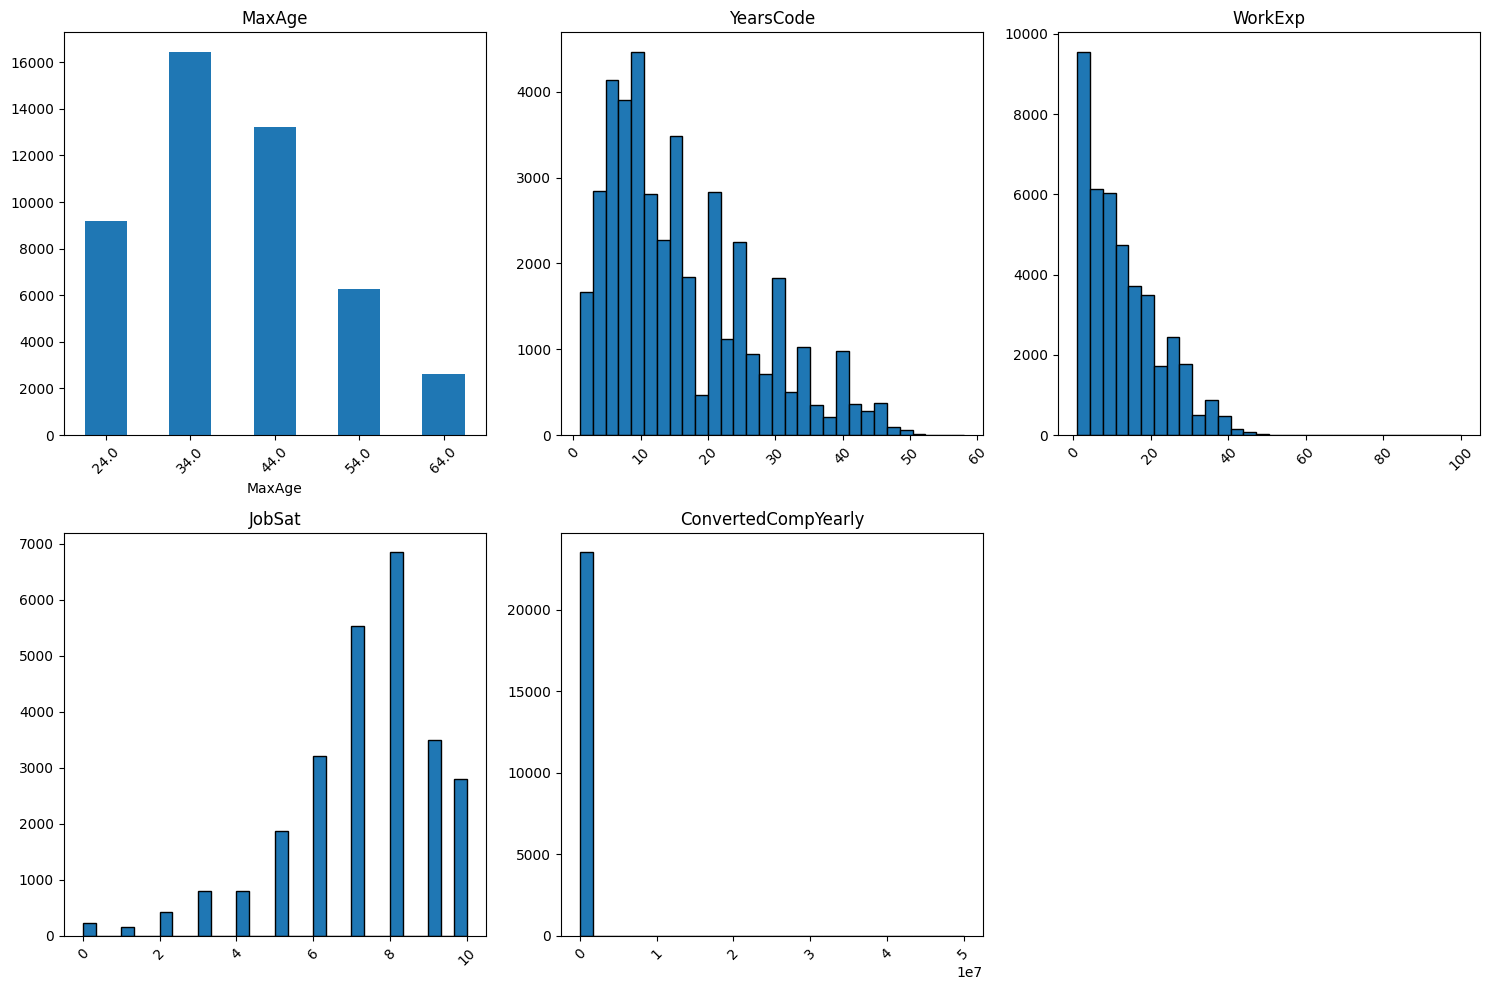

In [65]:
# Basic statistics
print("Basic Statistics:")
print(df[['MaxAge', 'YearsCode', 'WorkExp', 'JobSat', 'ConvertedCompYearly']].describe())

# Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())

# Visualize distributions
plt.figure(figsize=(15, 10))
for i, col in enumerate(['MaxAge', 'YearsCode', 'WorkExp', 'JobSat', 'ConvertedCompYearly'], 1):
    plt.subplot(2, 3, i)
    if df[col].nunique() > 10:
        plt.hist(df[col].dropna(), bins=30, edgecolor='black')
    else:
        df[col].value_counts().sort_index().plot(kind='bar')
    plt.title(col)
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [66]:
# Remove top 2% outliers from ConvertedCompYearly
threshold = df['ConvertedCompYearly'].quantile(0.90)
df = df[df['ConvertedCompYearly'] <= threshold]

# Remove any remaining missing values
df_clean = df.dropna(subset=['MaxAge', 'YearsCode', 'AgeNum','WorkExp', 'JobSat', 'ConvertedCompYearly', 'RemoteCategoryNum', 'TechEndorse_1', 'TechEndorse_2', 'TechEndorse_3', 'TechEndorse_4', 'TechEndorse_5', 'TechEndorse_6', 'TechEndorse_7', 'TechEndorse_8', 'TechEndorse_9', 'TechEndorse_13', 'TechOppose_1', 'TechOppose_2', 'TechOppose_3', 'TechOppose_5', 'TechOppose_7', 'TechOppose_9', 'TechOppose_11', 'TechOppose_13', 'TechOppose_16', 'ToolCountWork', 'ToolCountPersonal'])
# Check the shape after cleaning
print("Shape after cleaning:", df_clean.shape)

# Prepare features and target
X = df_clean[['MaxAge', 'YearsCode', 'WorkExp', 'JobSat', 'AgeNum', 'RemoteCategoryNum', 'TechEndorse_1', 'TechEndorse_2', 'TechEndorse_3', 'TechEndorse_4', 'TechEndorse_5', 'TechEndorse_6', 'TechEndorse_7', 'TechEndorse_8', 'TechEndorse_9', 'TechEndorse_13', 'TechOppose_1', 'TechOppose_2', 'TechOppose_3', 'TechOppose_5', 'TechOppose_7', 'TechOppose_9', 'TechOppose_11', 'TechOppose_13', 'TechOppose_16', 'ToolCountWork', 'ToolCountPersonal']]
y = df_clean['ConvertedCompYearly']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set size:", X_train_scaled.shape)
print("Test set size:", X_test_scaled.shape)

Shape after cleaning: (10779, 149)
Training set size: (8623, 27)
Test set size: (2156, 27)


In [67]:
# Initialize and train the model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_train = model.predict(X_train_scaled)
y_pred_test = model.predict(X_test_scaled)

# Print model coefficients
print("Intercept:", model.intercept_)
print("\nFeature coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef:.2f}")

Intercept: 74232.25176852608

Feature coefficients:
MaxAge: 122804.91
YearsCode: 7840.94
WorkExp: 7758.41
JobSat: 2412.44
AgeNum: -118223.94
RemoteCategoryNum: -4334.65
TechEndorse_1: 2519.76
TechEndorse_2: -407.26
TechEndorse_3: -694.85
TechEndorse_4: 2547.70
TechEndorse_5: -1486.07
TechEndorse_6: 1375.43
TechEndorse_7: 649.78
TechEndorse_8: -1892.07
TechEndorse_9: -1643.87
TechEndorse_13: -1413.84
TechOppose_1: 4320.78
TechOppose_2: 120.72
TechOppose_3: -3039.50
TechOppose_5: -697.59
TechOppose_7: -82.99
TechOppose_9: -2021.35
TechOppose_11: -1596.36
TechOppose_13: 718.87
TechOppose_16: -1202.61
ToolCountWork: -7.50
ToolCountPersonal: 246.09



Training Set Evaluation:
Mean Squared Error: 1661053963.56
Root Mean Squared Error: 40756.03
R² Score: 0.2476

Test Set Evaluation:
Mean Squared Error: 1605869486.83
Root Mean Squared Error: 40073.30
R² Score: 0.2211


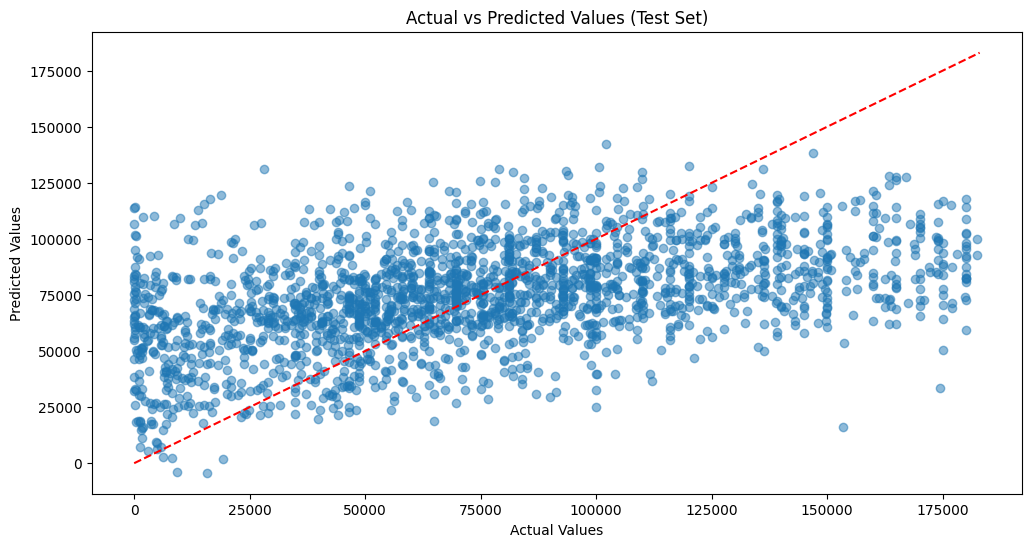

In [68]:
def evaluate_model(y_true, y_pred, set_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n{set_name} Set Evaluation:")
    print(f"Mean Squared Error: {mse:.2f}")
    print(f"Root Mean Squared Error: {rmse:.2f}")
    print(f"R² Score: {r2:.4f}")

# Evaluate on both training and test sets
evaluate_model(y_train, y_pred_train, "Training")
evaluate_model(y_test, y_pred_test, "Test")

# Plot actual vs predicted values
plt.figure(figsize=(12, 6))
plt.scatter(y_test, y_pred_test, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values (Test Set)')
plt.show()

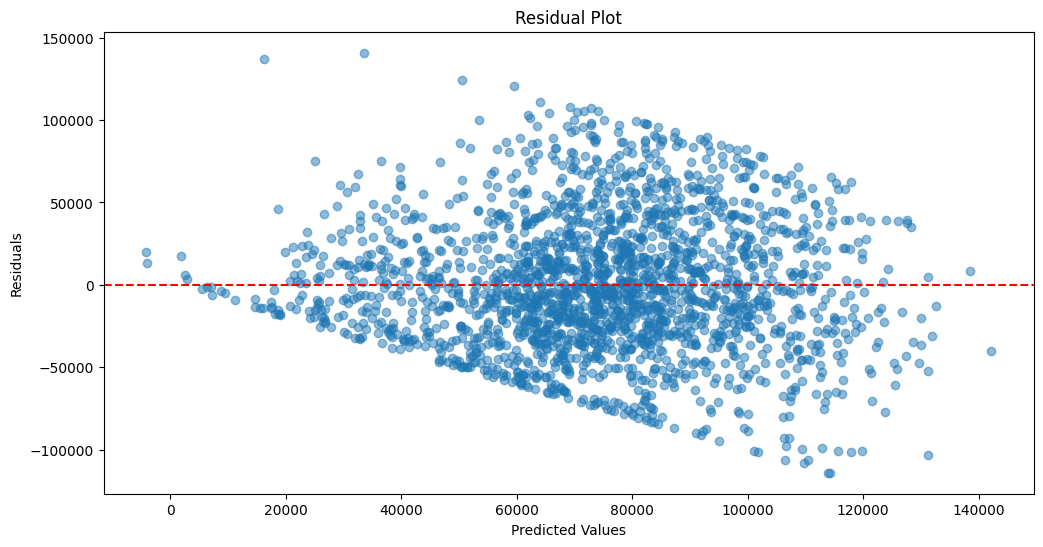

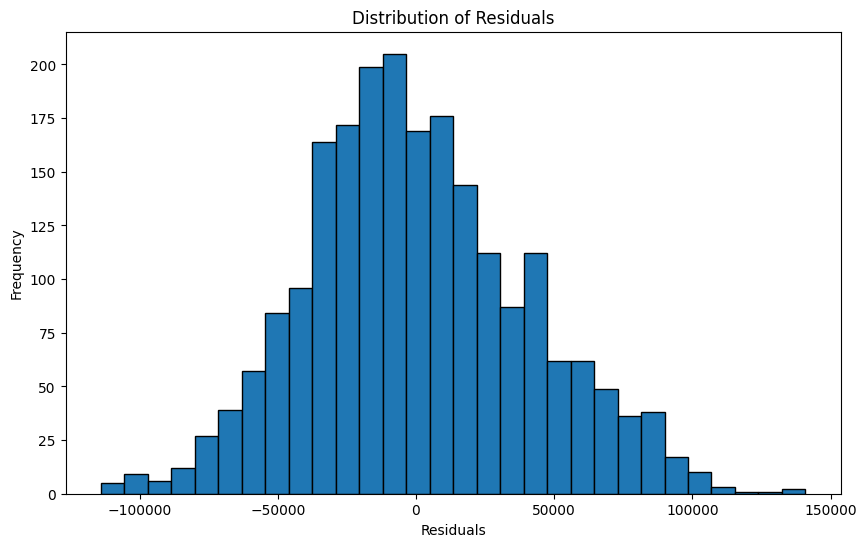

In [69]:
# Calculate residuals
residuals = y_test - y_pred_test

# Plot residuals
plt.figure(figsize=(12, 6))
plt.scatter(y_pred_test, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

# Check residual distribution
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=30, edgecolor='black')
plt.title('Distribution of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

Trainiere Random Forest Modell...

Out-of-Bag R² Score: 0.2882

Training Set Evaluation:
Mean Squared Error: 830967549.47
Root Mean Squared Error: 28826.51
R² Score: 0.5545

Test Set Evaluation:
Mean Squared Error: 1305838230.38
Root Mean Squared Error: 36136.38
R² Score: 0.2703

Top 10 wichtigste Features:
              Feature  Importance
3           YearsCode    0.145769
2             WorkExp    0.125570
0              MaxAge    0.064756
1              AgeNum    0.058053
38      ToolCountWork    0.028770
26     JobSatPoints_4    0.025555
15       TechOppose_1    0.025430
4   RemoteCategoryNum    0.024424
33    JobSatPoints_11    0.023218
5       TechEndorse_1    0.022788


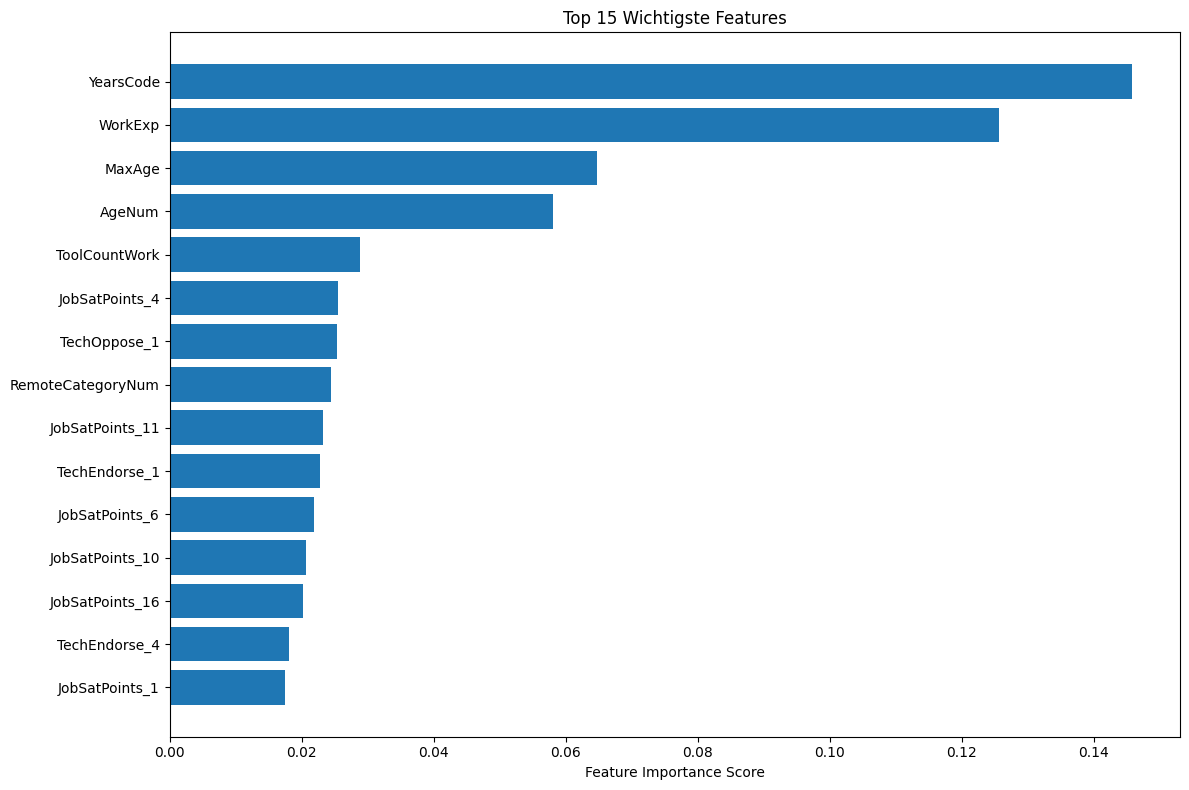

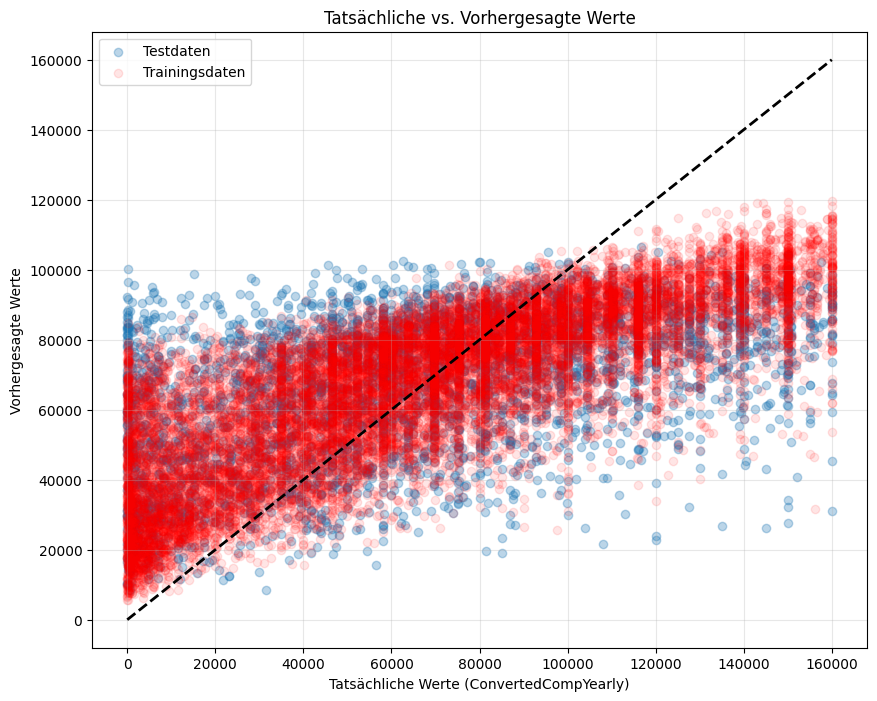

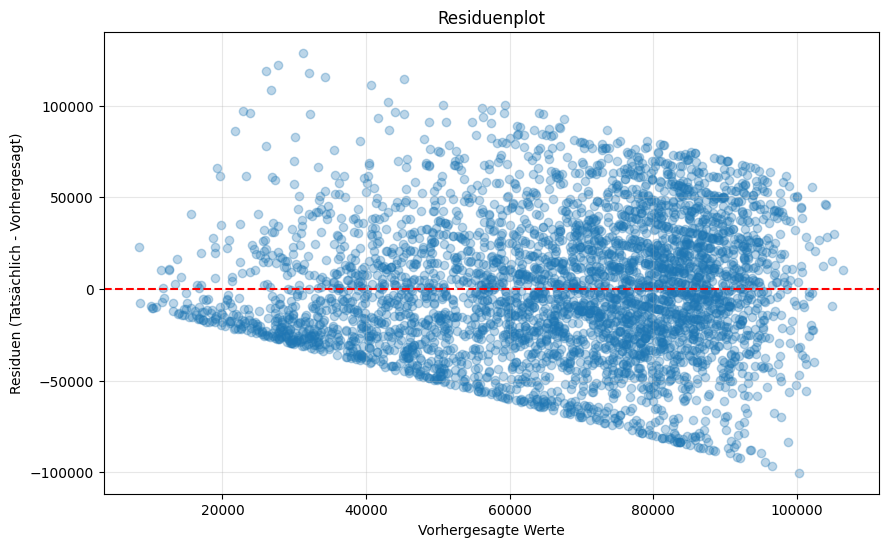

In [76]:
# 1. Importe
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 2. Wähle nur numerische Spalten aus
numerical_columns = [
    'MaxAge', 'AgeNum', 'WorkExp', 'YearsCode', 'RemoteCategoryNum',
    'TechEndorse_1', 'TechEndorse_2', 'TechEndorse_3', 'TechEndorse_4',
    'TechEndorse_5', 'TechEndorse_6', 'TechEndorse_7', 'TechEndorse_8',
    'TechEndorse_9', 'TechEndorse_13', 'TechOppose_1', 'TechOppose_2',
    'TechOppose_3', 'TechOppose_5', 'TechOppose_7', 'TechOppose_9',
    'TechOppose_11', 'TechOppose_13', 'TechOppose_16', 'TechOppose_15',
    'JobSatPoints_1', 'JobSatPoints_4', 'JobSatPoints_5', 'JobSatPoints_6',
    'JobSatPoints_7', 'JobSatPoints_8', 'JobSatPoints_9', 'JobSatPoints_10',
    'JobSatPoints_11', 'JobSatPoints_13', 'JobSatPoints_14', 'JobSatPoints_15',
    'JobSatPoints_16', 'ToolCountWork', 'ToolCountPersonal', 'JobSat'
]

# 3. Daten vorbereiten
X = df[numerical_columns].copy()
y = df['ConvertedCompYearly']

# Fehlende Werte mit Median füllen
X = X.fillna(X.median())
y = y.fillna(y.median())

# 4. Train-Test-Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Random Forest Modell mit optimierten Hyperparametern
rf_model = RandomForestRegressor(
    n_estimators=200,           # Erhöht die Anzahl der Bäume
    max_depth=15,               # Etwas tiefere Bäume erlauben
    min_samples_split=10,       # Reduziert für mehr Flexibilität
    min_samples_leaf=5,         # Reduziert für mehr Flexibilität
    max_features='sqrt',        # Wurzel der Anzahl der Features für jeden Split
    max_samples=0.8,            # Verwendet nur 80% der Daten für jeden Baum
    bootstrap=True,             # Bootstrap-Aggregating
    oob_score=True,            # Out-of-Bag Score berechnen
    n_jobs=-1,                 # Nutzt alle verfügbaren Kerne
    random_state=42
)

print("Trainiere Random Forest Modell...")
rf_model.fit(X_train, y_train)

# 6. Out-of-Bag Score ausgeben
print(f"\nOut-of-Bag R² Score: {rf_model.oob_score_:.4f}")

# 7. Vorhersagen machen
y_pred_train = rf_model.predict(X_train)
y_pred_test = rf_model.predict(X_test)

# 8. Modell evaluieren
def evaluate_model(y_true, y_pred, set_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n{set_name} Set Evaluation:")
    print(f"Mean Squared Error: {mse:.2f}")
    print(f"Root Mean Squared Error: {rmse:.2f}")
    print(f"R² Score: {r2:.4f}")

# 9. Ergebnisse ausgeben
evaluate_model(y_train, y_pred_train, "Training")
evaluate_model(y_test, y_pred_test, "Test")

# 10. Feature Importance anzeigen
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 wichtigste Features:")
print(feature_importance.head(10).to_string())

# 11. Feature Importance visualisieren
plt.figure(figsize=(12, 8))
plt.barh(feature_importance['Feature'][:15][::-1], 
         feature_importance['Importance'][:15][::-1])
plt.xlabel('Feature Importance Score')
plt.title('Top 15 Wichtigste Features')
plt.tight_layout()
plt.show()

# 12. Vorhersagen vs. tatsächliche Werte plotten
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred_test, alpha=0.3, label='Testdaten')
plt.scatter(y_train, y_pred_train, alpha=0.1, color='red', label='Trainingsdaten')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.xlabel('Tatsächliche Werte (ConvertedCompYearly)')
plt.ylabel('Vorhergesagte Werte')
plt.title('Tatsächliche vs. Vorhergesagte Werte')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 13. Residuenplot
residuals = y_test - y_pred_test
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_test, residuals, alpha=0.3)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Vorhergesagte Werte')
plt.ylabel('Residuen (Tatsächlich - Vorhergesagt)')
plt.title('Residuenplot')
plt.grid(True, alpha=0.3)
plt.show()

Trainiere CatBoost Modell...


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))


Training Set Evaluation:
Mean Squared Error: 48395570.00
Root Mean Squared Error: 6956.69
R² Score: 0.9741

Test Set Evaluation:
Mean Squared Error: 65070913.24
Root Mean Squared Error: 8066.65
R² Score: 0.9636

Top 10 wichtigste Features:
                   Feature  Importance
63               CompTotal   52.619796
62                Currency   26.155388
61                 Country    8.584652
7                  WorkExp    3.045077
12               YearsCode    2.772559
1                      Age    0.658410
140       AIAgentOrchWrite    0.499391
144        AIAgentExtWrite    0.494056
51         JobSatPoints_11    0.475176
95   OpSysProfessional use    0.426053


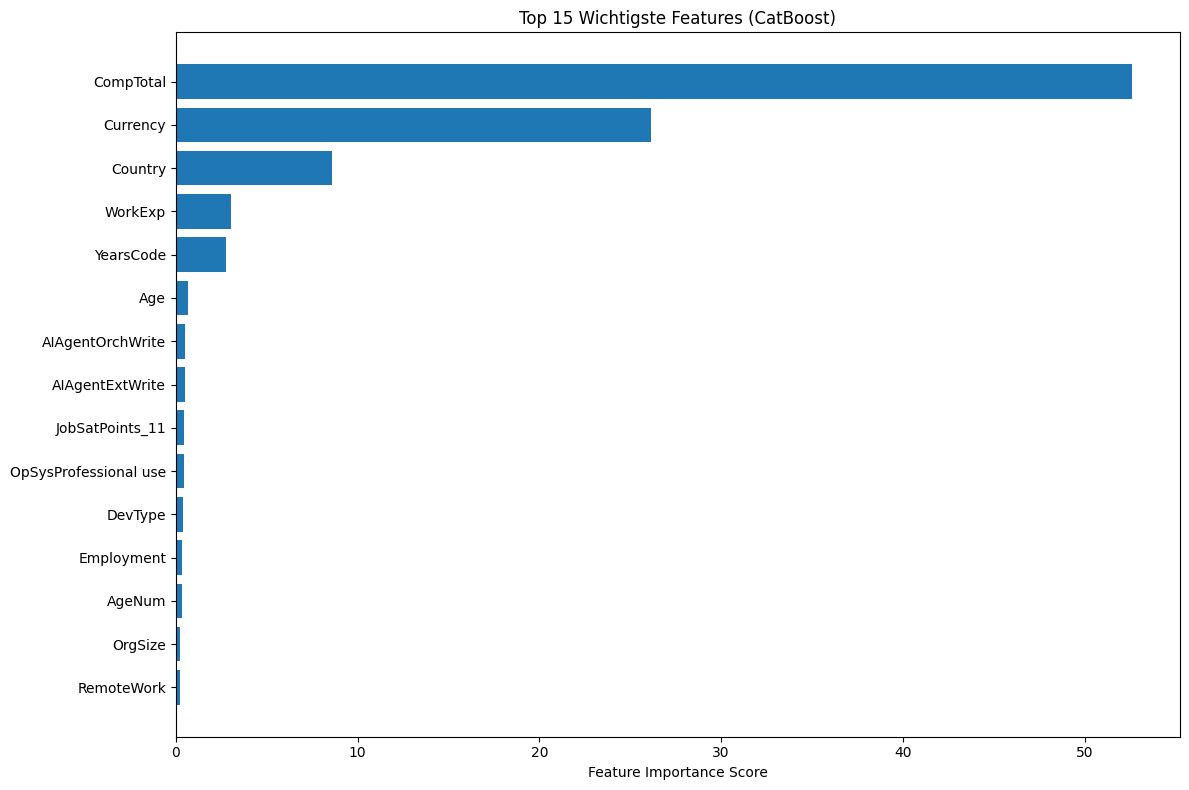

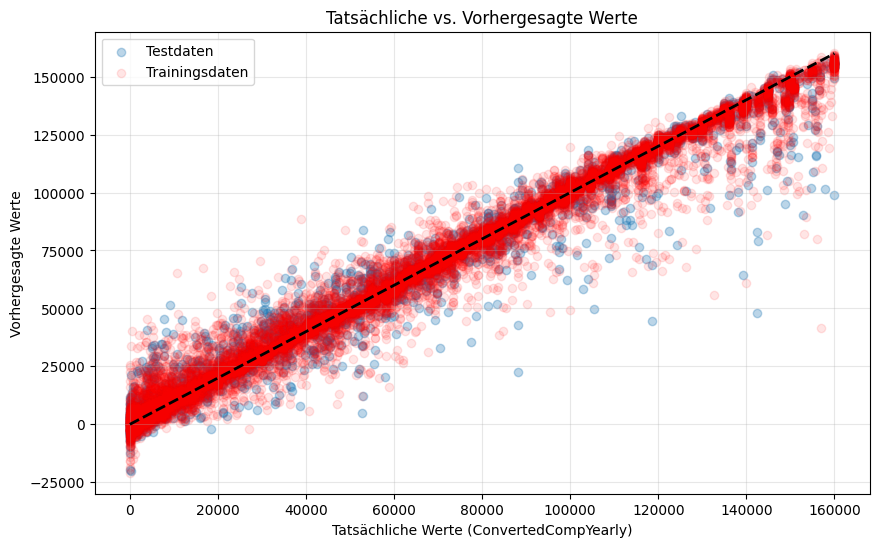

In [78]:
# CatBoost Modell mit automatischer Handhabung kategorialer Features
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

# 1. Daten vorbereiten
# Wähle alle Spalten außer der Zielvariable
X = df.drop('ConvertedCompYearly', axis=1)
y = df['ConvertedCompYearly'].fillna(df['ConvertedCompYearly'].median())

# 2. Identifiziere kategoriale Spalten
categorical_features = [col for col in X.columns if X[col].dtype == 'object']

# 3. Fülle fehlende Werte
# Für kategoriale Spalten: Fülle mit 'MISSING'
for col in categorical_features:
    X[col] = X[col].fillna('MISSING').astype(str)

# Für numerische Spalten: Fülle mit Median
for col in X.select_dtypes(include=['int64', 'float64']).columns:
    X[col] = X[col].fillna(X[col].median())

# 4. Train-Test-Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5. Konvertiere kategoriale Spalten zu Kategorien
for col in categorical_features:
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')

# 6. CatBoost Modell initialisieren
cat_model = CatBoostRegressor(
    iterations=1000,                # Anzahl der Bäume
    learning_rate=0.03,            # Lernrate
    depth=6,                       # Tiefe der Bäume
    cat_features=categorical_features,  # Kategoriale Features
    eval_metric='R2',              # Metrik zur Bewertung
    early_stopping_rounds=50,      # Frühes Stoppen bei keiner Verbesserung
    random_seed=42,
    verbose=100,                   # Zeigt Fortschritt an
    task_type='CPU',               # Kann auf 'GPU' geändert werden
    loss_function='RMSE'           # Verlustfunktion
)

print("Trainiere CatBoost Modell...")

# 7. Modell trainieren
cat_model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    plot=True,                    # Zeigt Trainingsfortschritt
    use_best_model=True,
    silent=True                   # Unterdrückt die Ausgabe während des Trainings
)

# 8. Vorhersagen machen
y_pred_train = cat_model.predict(X_train)
y_pred_test = cat_model.predict(X_test)

# 9. Modell evaluieren
def evaluate_model(y_true, y_pred, set_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n{set_name} Set Evaluation:")
    print(f"Mean Squared Error: {mse:.2f}")
    print(f"Root Mean Squared Error: {rmse:.2f}")
    print(f"R² Score: {r2:.4f}")

# 10. Ergebnisse ausgeben
evaluate_model(y_train, y_pred_train, "Training")
evaluate_model(y_test, y_pred_test, "Test")

# 11. Feature Importance anzeigen
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': cat_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 wichtigste Features:")
print(feature_importance.head(10).to_string())

# 12. Feature Importance visualisieren
plt.figure(figsize=(12, 8))
plt.barh(feature_importance['Feature'][:15][::-1], 
         feature_importance['Importance'][:15][::-1])
plt.xlabel('Feature Importance Score')
plt.title('Top 15 Wichtigste Features (CatBoost)')
plt.tight_layout()
plt.show()

# 13. Vorhersagen vs. tatsächliche Werte plotten
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_test, alpha=0.3, label='Testdaten')
plt.scatter(y_train, y_pred_train, alpha=0.1, color='red', label='Trainingsdaten')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.xlabel('Tatsächliche Werte (ConvertedCompYearly)')
plt.ylabel('Vorhergesagte Werte')
plt.title('Tatsächliche vs. Vorhergesagte Werte')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()